In [1]:
import matplotlib.pyplot as plt
import glob
import numpy as np
import pandas as pd
import math
import seaborn as sns

import sys, os, platform, glob, zipfile, math, shutil, random, gc, json, re, pathlib
from scipy.optimize import curve_fit
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC

from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
file_path = '/content/drive/MyDrive/ml files/updatedmuon.csv'

df = pd.read_csv(file_path)

print(df)

In [ ]:
track_df = df[(df['trackType'] == 3)]
cut_df = track_df[(track_df['p'] > 4) & (track_df['eta'] >= -4) & (track_df['eta'] <= -2.5) & (track_df['pt'] > 0.5)] #consists of the chi2, track type & momentum cuts needed

filter_df = cut_df[(cut_df['chi2'] <= 10)]

In [ ]:
cut_df.to_csv('cutsapplied(nochi2).csv', index=False)
cut_df.to_csv('/content/drive/MyDrive/ml files/cutsapplied(nochi2).csv', index=False)

In [ ]:
filter_df.to_csv('cutsapplied.csv', index=False)
filter_df.to_csv('/content/drive/MyDrive/ml files/cutsapplied.csv', index=False)

In [ ]:
signalD = [abs(411), abs(421), abs(431), abs(4122), abs(4232), abs(4132)]
signalB = [abs(521), abs(511), abs(531), abs(5232), abs(5132), abs(5122)]
signalPDG = [abs(411), abs(421), abs(431), abs(4122), abs(4232), abs(4132), abs(521), abs(511), abs(531), abs(5232), abs(5132), abs(5122)]


In [ ]:
label = []

for index, row in cut_df.iterrows():
  pdg = abs(row['motherPDG'])
  if pdg in signalPDG:
    label.append("s")   # B meson signal
  else:
    label.append("b")   # background

cut_df['label'] = label

In [ ]:
cut_df

In [ ]:
pdg = cut_df['motherPDG']

pdg.value_counts()

In [ ]:
l = cut_df['label']
l.value_counts()

In [ ]:
print(cut_df.info())

In [ ]:
cut_df['y'] = (cut_df["label"] == "s").astype(int)

y = cut_df['y'].to_numpy()

In [ ]:
weight = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
print(weight)

In [ ]:
cut_df['w'] = np.where(cut_df['y'] == 1, weight[1], weight[0])
w = cut_df['w']

In [ ]:
w.value_counts()

In [ ]:
cut_df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Exclude columns not to be used as input features
FEATURE_EXCLUDE = ['trackType', 'motherPDG', 'mcID', 'trackID', 'collisionID', 'chi2MatchMCHMID', 'isPrompt', 'nClusters', 'sign' ,'label', 'y', 'w']
features = [c for c in cut_df.columns if c not in FEATURE_EXCLUDE]

In [ ]:
x_raw = cut_df[features].copy()

In [ ]:
x_raw

In [ ]:
imputer = SimpleImputer(strategy="median")
x_imputed = imputer.fit_transform(x_raw)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_imputed)

#xb_train, xb_test, yb_train, yb_test, wb_train, wb_test = train_test_split(xb_scaled, yb, wb, test_size=0.2, random_state=42, stratify=yb)

x_train, x_test, y_train, y_test, w_train, w_test = train_test_split(x_scaled, y, w, test_size=0.2, random_state=42, stratify=y)

print("Num features:", len(features))
x_train.shape, x_test.shape

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=25, random_state=42)
random_forest.fit(x_train, y_train)

In [ ]:
importances = random_forest.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
bars = plt.bar(range(x_raw.shape[1]), importances[indices], color='red', alpha=0.8, linewidth=1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom", size=8)

plt.ylabel("Importance")
plt.xticks(range(x_raw.shape[1]), np.array(x_raw.columns)[indices], rotation=90, size=12)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

keras.backend.clear_session()

def make_mlp(input_dim, hidden=[30, 30, 30], drop=0.2, l2=0.0):
    """
    Build a binary-classification MLP.

    Args:
        input_dim (int): number of input features (columns) after preprocessing.
        hidden (list[int]): how many neurons (units) to put in each hidden layer.
                            Example [256,128,64] means 3 hidden layers with those widths.
        drop (float): dropout rate (0.0–0.5 typical). Dropout randomly turns off a
                      fraction of neurons during training to reduce overfitting.
        l2 (float): L2 weight regularization strength (a small penalty on large weights).
                    Helps keep the model simpler and more generalizable.

    Returns:
        keras.Model: a compiled model ready to train with model.fit(...)
    """

    # ----- 1) Define the input “place holder” -----
    # Shape=(input_dim,) means the model expects a 1D vector of length input_dim for each row.
    inputs = keras.Input(shape=(input_dim,), name="features")

    # We'll wire layers onto this tensor "x". We start with x=inputs.
    x = inputs

    # ----- 2) Hidden layers (the actual “learning” happens here) -----
    # We loop over the list "hidden" so it’s easy to change depth/width from the function call.
    for i, h in enumerate(hidden, start=1):
        # Dense = fully connected layer. 'h' controls how many neurons (capacity).
        # activation='relu' is a standard nonlinearity that helps the network learn complex patterns.
        # kernel_regularizer adds the L2 penalty (weight decay) to fight overfitting.
        x = layers.Dense(
            h,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2),
            name=f"dense_{i}"
        )(x)

        # Batch Normalization stabilizes and speeds up training by normalizing activations
        # inside the network (per mini-batch). This often allows slightly higher learning rates.
        x = layers.BatchNormalization(name=f"bn_{i}")(x)

        # Dropout randomly zeroes out a fraction `drop` of activations during training.
        # Think of it as creating slightly different sub-networks each step, which prevents
        # the model from relying too heavily on any single path (“co-adaptation”).
        x = layers.Dropout(drop, name=f"drop_{i}")(x)

    # ----- 3) Output layer -----
    # We have a **binary** classification problem (signal vs background),
    # so we produce ONE number in [0,1] using 'sigmoid'.
    # This can be interpreted as P(y=1 | x) = probability of signal.
    outputs = layers.Dense(1, activation="sigmoid", name="logit")(x)

    # ----- 4) Build the model graph -----
    model = keras.Model(inputs, outputs, name="mlp_higgs")

    # ----- 5) Choose optimizer, loss, and metrics -----
    # Optimizer: Adam is a good default that adapts the learning rate during training.
    # Loss: binary cross-entropy is the standard for binary classification.
    # Metrics:
    #   - AUC (ROC-AUC): threshold-free measure of ranking quality.
    #   - Precision & Recall: computed at a default threshold (0.5) — useful but threshold-dependent.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    return model

# ----- 6) Create the model -----
# X_train.shape[1] is “how many feature columns do we have?”
# We use 3 hidden layers with widths 256 → 128 → 64, 20% dropout, tiny L2 penalty.
mlp = make_mlp(
    input_dim=x_train.shape[1],
    hidden=[30, 30, 30],
    drop=0.2,
    l2=1e-6
)

# Show a summary table of the layers, shapes, and parameter counts.
mlp.summary()

In [ ]:
history = mlp.fit(
    x_train, y_train,
    sample_weight=w_train,              # <-- important: use sample weights
    validation_data=(x_test, y_test, w_test),
    epochs=50,
    batch_size=100,
    verbose=1
)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - auc: 0.6054 - loss: 0.7714 - precision: 0.5330 - recall: 0.6141 - val_auc: 0.7773 - val_loss: 0.6182 - val_precision: 0.6309 - val_recall: 0.7825
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7385 - loss: 0.6143 - precision: 0.6409 - recall: 0.6635 - val_auc: 0.7936 - val_loss: 0.5696 - val_precision: 0.6816 - val_recall: 0.6951
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7435 - loss: 0.6053 - precision: 0.6559 - recall: 0.6515 - val_auc: 0.7945 - val_loss: 0.5500 - val_precision: 0.7037 - val_recall: 0.6795
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.7515 - loss: 0.5971 - precision: 0.6540 - recall: 0.6574 - val_auc: 0.8008 - val_loss: 0.5407 - val_precision: 0.6980 - val_recall: 0.6951
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7599 - loss: 0.5835 - precision: 0.6613 - recall: 0.6541 - val_auc: 0.8028 - val_loss: 0.5366 - val_precision: 0.7076 - val_recall: 0.7076
Epoch 6/5

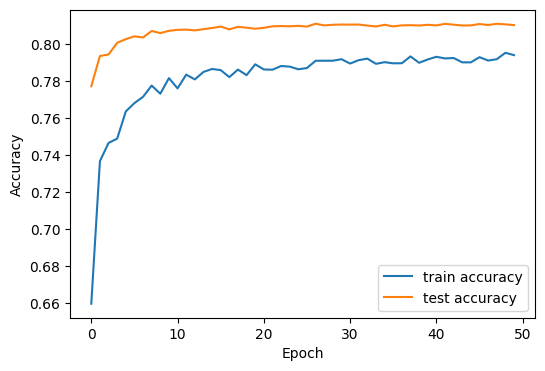

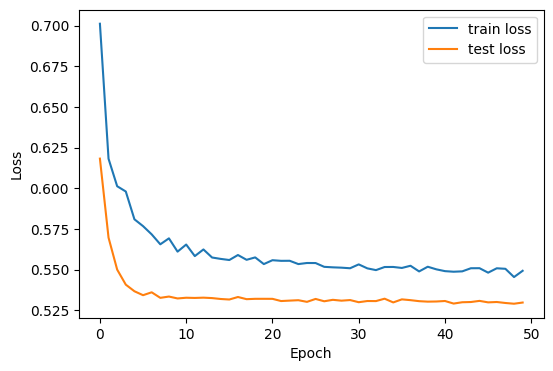

In [ ]:
h = history.history
plt.figure(figsize=(6,4))
plt.plot(h['auc'], label='train accuracy')
plt.plot(h['val_auc'], label='test accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(h['loss'], label='train loss')
plt.plot(h['val_loss'], label='test loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

In [ ]:
#WITH WEIGHTS

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

proba_test_nn = mlp.predict(x_test, batch_size=2048).ravel()
pred_test_nn_05 = (proba_test_nn >= 0.5).astype(int)


metrics_nn_weighted = {
    "Accuracy": accuracy_score(y_test, pred_test_nn_05, sample_weight= w_test),
    "F1": f1_score(y_test, pred_test_nn_05, sample_weight=w_test),
    "ROC_AUC": roc_auc_score(y_test, proba_test_nn, sample_weight=w_test),
    "ConfusionMatrix": confusion_matrix(y_test, pred_test_nn_05, sample_weight=w_test)
}
metrics_nn_weighted

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


{'Accuracy': 0.7241649489621206,
 'F1': 0.7165181617890768,
 'ROC_AUC': np.float64(0.8103824924090601),
 'ConfusionMatrix': array([[772.92251595, 256.07748405],
        [311.59105099, 717.40894901]])}

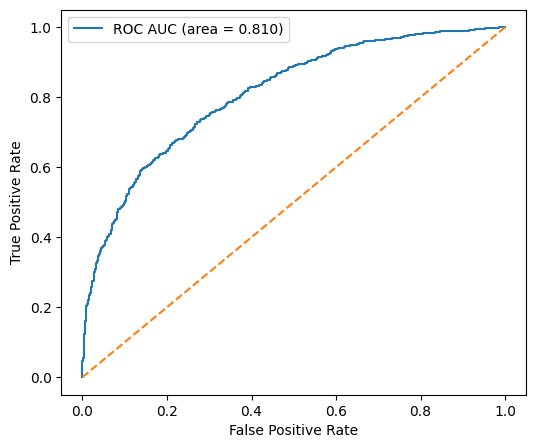

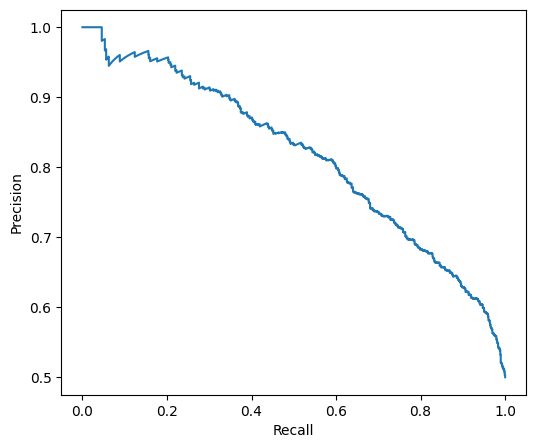

Weighted confusion matrix (threshold=0.5):
 [[772.92251595 256.07748405]
 [311.59105099 717.40894901]]


In [ ]:
# ROC
fpr, tpr, thresholds = roc_curve(y_test, proba_test_nn, sample_weight= w_test)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC (area = {roc_auc_score(y_test, proba_test_nn, sample_weight= w_test):.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

# PR
prec, rec, thr = precision_recall_curve(y_test, proba_test_nn, sample_weight= w_test)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

print("Weighted confusion matrix (threshold=0.5):\n", metrics_nn_weighted["ConfusionMatrix"])

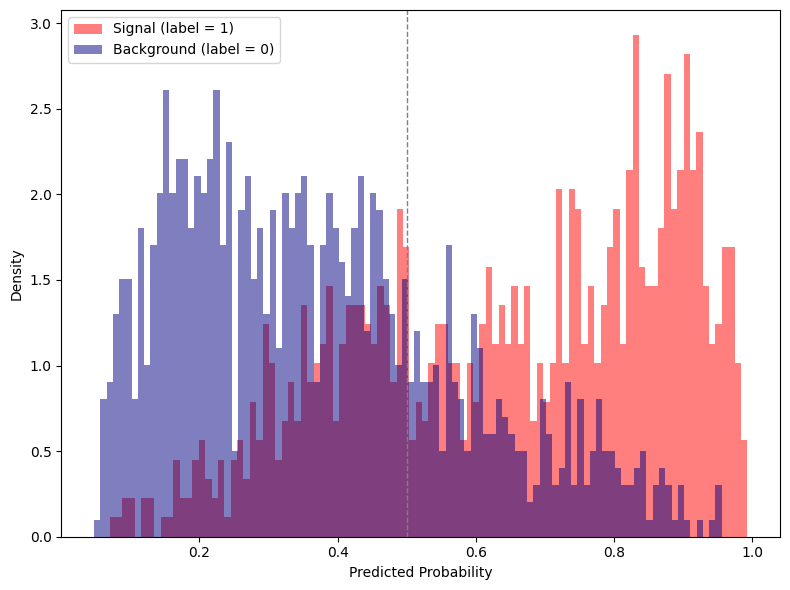

In [ ]:
signal = proba_test_nn[y_test == 1]
background = proba_test_nn[y_test == 0]

plt.figure(figsize=(8,6))

plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)

plt.hist(signal, bins=100, density=True, alpha=0.5, label='Signal (label = 1)', color='red')
plt.hist(background, bins=100, density=True, alpha=0.5, label='Background (label = 0)', color='navy')

plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
#plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

True Negatives (TN): 772.9225159526078
False Positives (FP): 256.07748404740113
False Negatives (FN): 311.59105098855474
True Positives (TP): 717.4089490114495


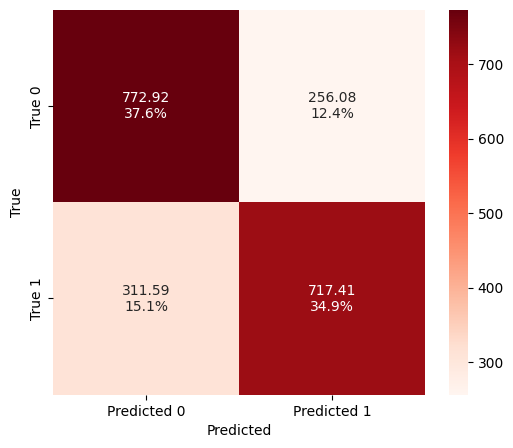

In [ ]:
cmweighted = confusion_matrix(y_test, pred_test_nn_05, sample_weight=w_test)

tn, fp, fn, tp = cmweighted.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


cm_percent_weight = cmweighted / cmweighted.sum()

labels = np.array([["{0:.2f}\n{1:.1%}".format(value, cm_percent_weight[i, j])
                    for j, value in enumerate(row)] for i, row in enumerate(cmweighted)])

plt.figure(figsize=(6,5))
sns.heatmap(cmweighted, annot=labels, fmt="", cmap="Reds", cbar=True,
            xticklabels=["Predicted 0","Predicted 1"],
            yticklabels=["True 0","True 1"])


plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


In [ ]:
precision = precision_score(y_test, pred_test_nn_05)
recall = recall_score(y_test, pred_test_nn_05)

print(recall)
print(precision)

0.6971904266389178
0.7104984093319194


In [ ]:
#WITHOUT WEIGHTS

In [ ]:
metrics_unweighted = {
    "Accuracy": accuracy_score(y_test, pred_test_nn_05),
    "F1": f1_score(y_test, pred_test_nn_05),
    "ROC_AUC": roc_auc_score(y_test, proba_test_nn),
    "ConfusionMatrix": confusion_matrix(y_test, pred_test_nn_05)
}
metrics_unweighted

{'Accuracy': 0.7259475218658892,
 'F1': 0.7037815126050421,
 'ROC_AUC': np.float64(0.8103824924090581),
 'ConfusionMatrix': array([[824, 273],
        [291, 670]])}

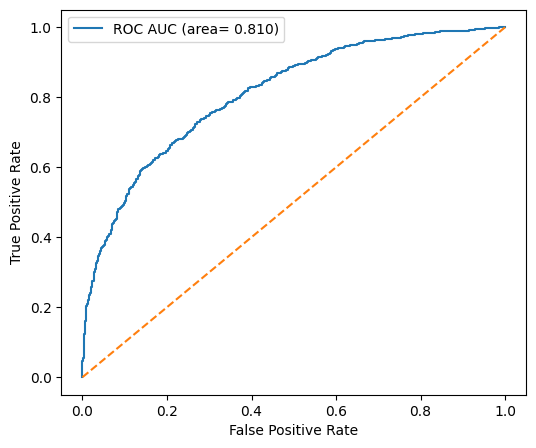

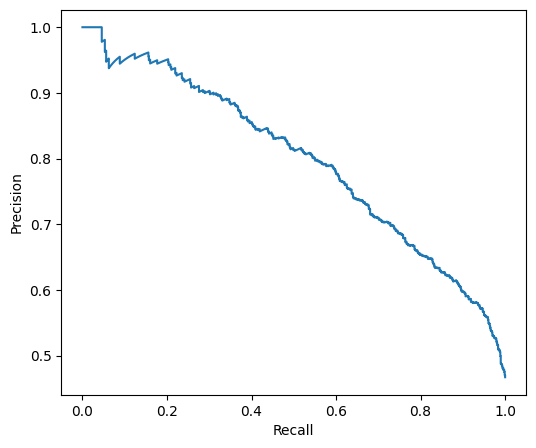

Unweighted confusion matrix (threshold=0.5):
 [[824 273]
 [291 670]]


In [ ]:
# ROC
fpr, tpr, thresholds = roc_curve(y_test, proba_test_nn)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC (area= {roc_auc_score(y_test, proba_test_nn):.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

# PR
prec, rec, thr = precision_recall_curve(y_test, proba_test_nn)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

print("Unweighted confusion matrix (threshold=0.5):\n", metrics_unweighted["ConfusionMatrix"])

True Negatives (TN): 824
False Positives (FP): 273
False Negatives (FN): 291
True Positives (TP): 670


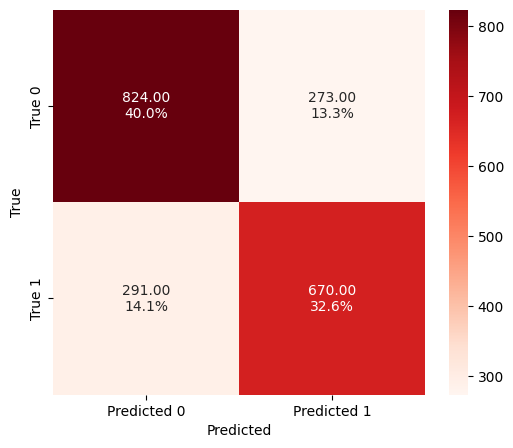

In [ ]:
cm = confusion_matrix(y_test, pred_test_nn_05)

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


cm_percent = cm / cm.sum()

labels = np.array([["{0:.2f}\n{1:.1%}".format(value, cm_percent[i, j])
                    for j, value in enumerate(row)] for i, row in enumerate(cm)])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Reds", cbar=True,
            xticklabels=["Predicted 0","Predicted 1"],
            yticklabels=["True 0","True 1"])

plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()
